# Los ríos del Himalaya están serpenteando casi al doble de velocidad

**1,8× más rápido.** Esa es la mediana de cuánto aceleró la migración lateral de 650 meandros entre dos periodos: 1980–2000 y 2000–2020. Y no es un puñado de ríos: el 93% de los meandros pareados se movió más rápido en la segunda ventana que en la primera.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-14-rios-himalaya-meandros-clima/notebook.ipynb)

**Paper:** *Accelerated Himalayan river meandering and dynamics due to climate change* · Lin et al., **Science** (2026) · [DOI: 10.1126/science.adg8401](https://doi.org/10.1126/science.adg8401)

**Datos:** [Zenodo 10.5281/zenodo.17853501](https://doi.org/10.5281/zenodo.17853501) — 650 meandros con métricas pareadas en 3 cuencas mayores del Himalaya, más una segunda tabla con clima por década en 9 sub-tributarios.

**Video:** [Ver en YouTube](https://youtube.com/shorts/NtBdIb3JngA)

## El experimento natural

Lin y su equipo cruzaron imágenes de satélite con trabajo de campo en tres cuencas grandes del Himalaya — Yarlung Tsangpo, Ganges, Indus — y por cada meandro calcularon los metros que migra lateralmente al año, en dos ventanas: T1 (1980s–90s) y T2 (2000s–10s).

Como son **los mismos meandros** medidos dos veces, podemos hacer una comparación pareada — no estamos comparando ríos distintos, sino el mismo río consigo mismo cuatro décadas después. Veamos qué cambió.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_T1 = '#BBBBBB'       # gris — pasado (1980s-90s)
COLOR_T2 = '#2563EB'       # azul CaM — presente (2000s-10s)
COLOR_ALERTA = '#DC2626'   # rojo — línea diagonal de referencia
COLOR_AMBAR = '#D97706'    # ámbar — anotaciones
COLOR_CONTEXTO = '#999999'

FUENTE = 'Fuente: Lin et al. (2026), Science — DOI 10.1126/science.adg8401 | Datos: Zenodo 17853501'

# ══════════════════════════════════════════════════════════════
# Imports + estilo + carga
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr

# Estilo CaM (local → tmpfs → GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Crear carpeta de figuras
os.makedirs('figuras', exist_ok=True)

# Cargar los 2 datasets
pareados = pd.read_csv('datos/meandros_pareados.csv')
clima = pd.read_csv('datos/clima_y_migracion_por_decada.csv')

# Resumen
print(f'Meandros pareados:  {len(pareados):>4d}  (T1=1980s-90s, T2=2000s-10s)')
print('Por cuenca:')
for c, n in pareados['cuenca'].value_counts().items():
    print(f'  {c:20s}  n={n}')
print(f'\nClima por década:   {len(clima):>4d} observaciones · 4 décadas · 9 sub-tributarios')

Meandros pareados:   650  (T1=1980s-90s, T2=2000s-10s)
Por cuenca:
  Yarlung_Tsangpo       n=487
  Ganges                n=82
  Indus                 n=81

Clima por década:   2600 observaciones · 4 décadas · 9 sub-tributarios


## Aquí está.

Cada punto es un meandro. El eje horizontal es cuánto migró por año en T1; el vertical, cuánto migró en T2. La línea diagonal roja es la frontera: si un punto cae por encima, ese meandro se movió más rápido en el segundo periodo.

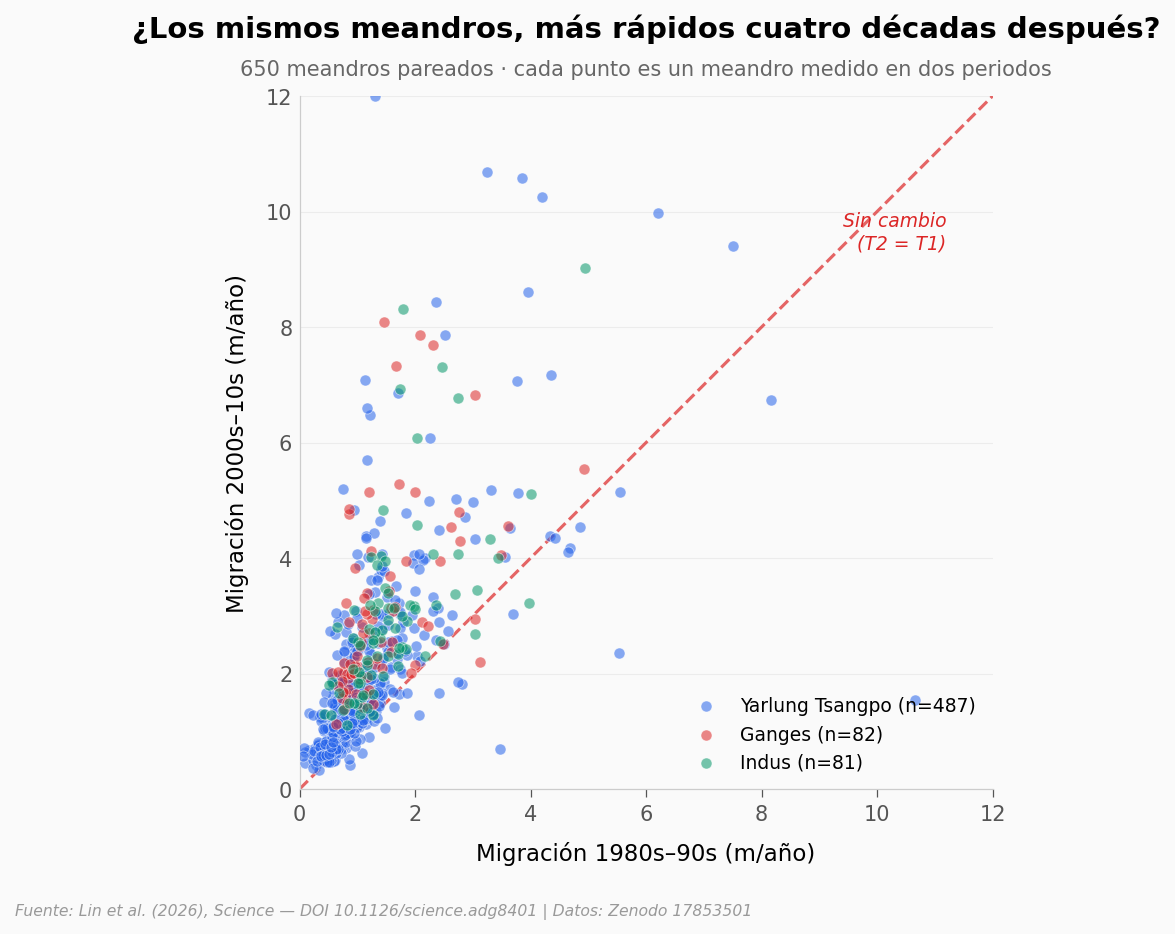

In [2]:
# Hero: T1 vs T2 pareado, coloreado por cuenca
fig, ax = plt.subplots(figsize=(11, 6))

cuenca_colors = {
    'Yarlung_Tsangpo': '#2563EB',
    'Ganges': '#DC2626',
    'Indus': '#059669',
}
cuenca_labels = {
    'Yarlung_Tsangpo': 'Yarlung Tsangpo (n=487)',
    'Ganges': 'Ganges (n=82)',
    'Indus': 'Indus (n=81)',
}

# Diagonal de referencia
lim = 12
ax.plot([0, lim], [0, lim], color=COLOR_ALERTA, linewidth=1.5, linestyle='--',
        alpha=0.7, zorder=2)
ax.text(11.2, 10.0, 'Sin cambio\n(T2 = T1)', fontsize=9, color=COLOR_ALERTA,
        ha='right', va='top', style='italic')

for cuenca, color in cuenca_colors.items():
    g = pareados[pareados['cuenca'] == cuenca]
    ax.scatter(g['migration_m_yr_t1'], g['migration_m_yr_t2'],
               color=color, s=28, alpha=0.55, edgecolors='white',
               linewidths=0.4, zorder=5, label=cuenca_labels[cuenca])

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('Migración 1980s–90s (m/año)', fontsize=11)
ax.set_ylabel('Migración 2000s–10s (m/año)', fontsize=11)
ax.set_title('¿Los mismos meandros, más rápidos cuatro décadas después?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '650 meandros pareados · cada punto es un meandro medido en dos periodos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower right', framealpha=0.92)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color=COLOR_CONTEXTO, style='italic')
plt.savefig('figuras/hero_pareado.png', dpi=200, bbox_inches='tight')
plt.show()

## Casi todos cruzaron al lado de arriba

El **93,2%** de los meandros (606 de 650) migró más rápido en T2 que en T1. La mediana del ritmo de migración pasó de **1,02 m/año a 1,81 m/año** — un factor de **1,77×**. La prueba de Wilcoxon pareada da p ≈ 10⁻⁹², es decir, el cambio no es ruido aleatorio.

Con un Cohen's d pareado de **0,72**, el efecto es de magnitud mediana–grande para una variable geomorfológica. Es bastante.

## Pero la aceleración no es uniforme

El Yarlung Tsangpo aporta tres de cada cuatro meandros del estudio — su comportamiento domina el promedio. Si lo separamos del Ganges y del Indus, aparecen tres historias distintas.

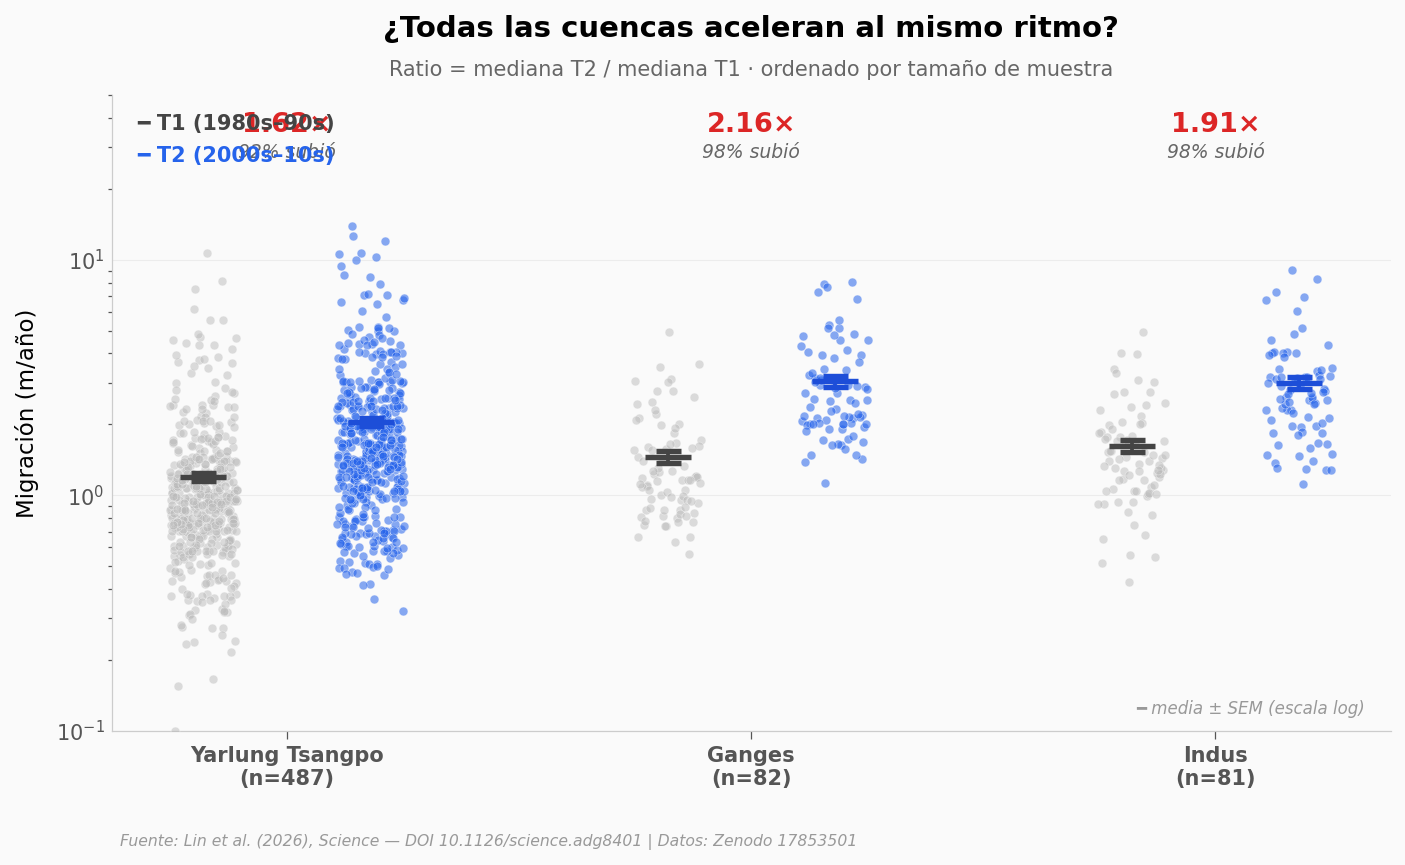

In [3]:
# Comparación por cuenca: jitter + media + SEM en escala log
fig, ax = plt.subplots(figsize=(11, 5.5))

orden_cuencas = ['Yarlung_Tsangpo', 'Ganges', 'Indus']
labels_cuencas = ['Yarlung Tsangpo\n(n=487)', 'Ganges\n(n=82)', 'Indus\n(n=81)']

np.random.seed(42)
positions = []
for i, cuenca in enumerate(orden_cuencas):
    g = pareados[pareados['cuenca'] == cuenca]
    base_x = i * 2.5
    pos_t1 = base_x
    pos_t2 = base_x + 0.9
    positions.extend([pos_t1, pos_t2])

    for pos, vals, color, alpha in [(pos_t1, g['migration_m_yr_t1'], COLOR_T1, 0.5),
                                     (pos_t2, g['migration_m_yr_t2'], COLOR_T2, 0.55)]:
        n = len(vals)
        x_strip = np.linspace(pos - 0.18, pos + 0.18, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=color, s=18, alpha=alpha,
                   edgecolors='white', linewidths=0.3, zorder=5)
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        edge = '#444444' if color == COLOR_T1 else '#1d4ed8'
        ax.errorbar(pos, mean, yerr=sem, fmt='_', color=edge,
                    markersize=22, markeredgewidth=2.6,
                    capsize=6, capthick=1.5, zorder=6)

    # Ratio anotado encima
    t1m = g['migration_m_yr_t1'].median()
    t2m = g['migration_m_yr_t2'].median()
    ratio = t2m / t1m
    pct = (g['migration_m_yr_t2'] > g['migration_m_yr_t1']).mean() * 100
    ax.text((pos_t1 + pos_t2) / 2, 35, f'{ratio:.2f}×',
            fontsize=13, fontweight='bold', color=COLOR_ALERTA, ha='center')
    ax.text((pos_t1 + pos_t2) / 2, 27, f'{pct:.0f}% subió',
            fontsize=9, color='#666666', ha='center', style='italic')

ax.set_yscale('log')
ax.set_ylim(0.1, 50)
ax.set_xticks([(i * 2.5 + 0.45) for i in range(3)])
ax.set_xticklabels(labels_cuencas, fontsize=10, fontweight='bold')

# Mini leyenda T1 / T2
ax.text(0.02, 0.97, '━ T1 (1980s–90s)', transform=ax.transAxes,
        fontsize=10, color='#444444', va='top', fontweight='bold')
ax.text(0.02, 0.92, '━ T2 (2000s–10s)', transform=ax.transAxes,
        fontsize=10, color=COLOR_T2, va='top', fontweight='bold')
ax.text(0.98, 0.02, '━ media ± SEM (escala log)', transform=ax.transAxes,
        fontsize=8, color=COLOR_CONTEXTO, ha='right', va='bottom', style='italic')

ax.set_ylabel('Migración (m/año)', fontsize=11)
ax.set_title('¿Todas las cuencas aceleran al mismo ritmo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ratio = mediana T2 / mediana T1 · ordenado por tamaño de muestra',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color=COLOR_CONTEXTO, style='italic')
plt.savefig('figuras/por_cuenca.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué cambió en cuatro décadas para que los ríos se muevan más?

El paper apunta al clima: temperaturas más altas amplificarían el agua de deshielo y desestabilizarían las orillas congeladas. Es una hipótesis razonable, pero la comparación pareada no la prueba — solo describe el resultado. Para ver si la pista climática aguanta, miremos qué hicieron las variables ambientales en las mismas cuatro décadas.

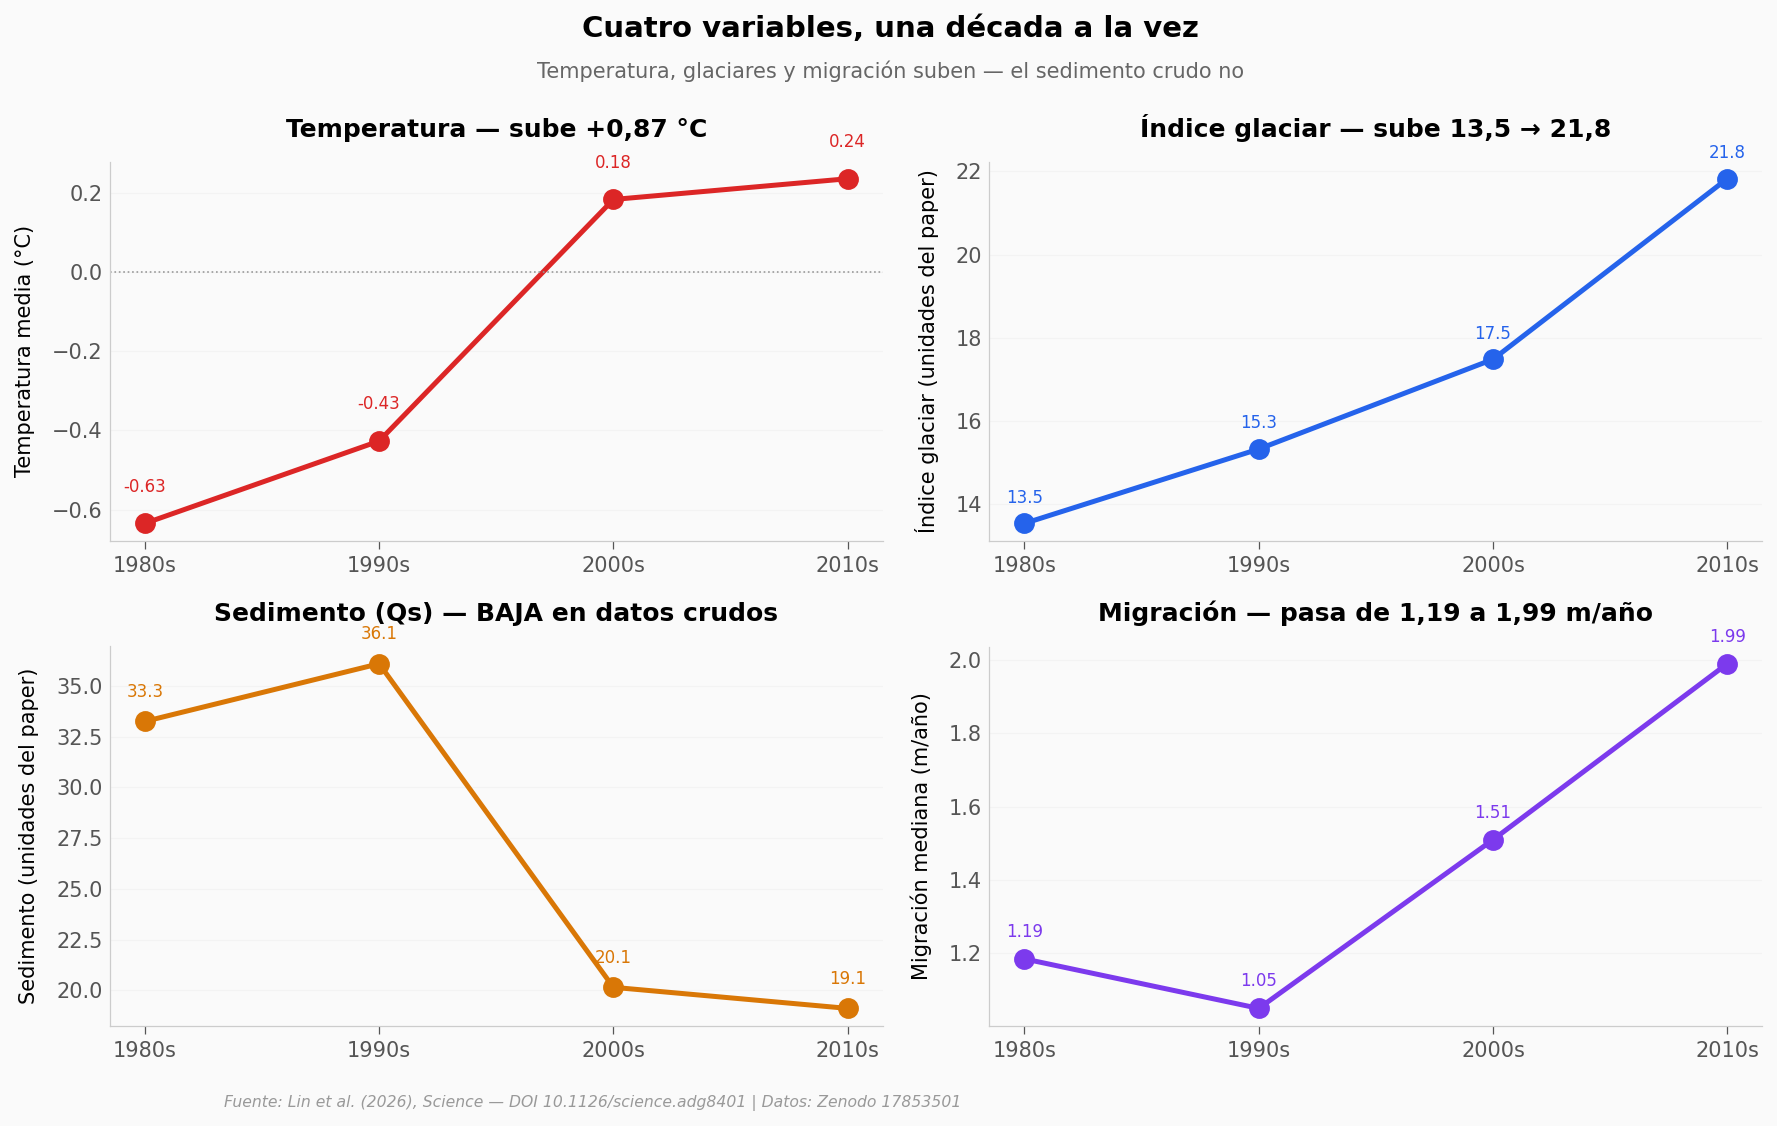

In [4]:
# Drivers climáticos + migración por década (4 paneles)
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
decadas = ['1980s', '1990s', '2000s', '2010s']

def stat_por_decada(serie_name, agg='mean'):
    out = []
    for d in decadas:
        s = clima[clima['decada'] == d][serie_name].dropna()
        out.append(s.mean() if agg == 'mean' else s.median())
    return out

# Panel 1: temperatura
ax = axes[0, 0]
temps = stat_por_decada('temp_C', 'mean')
ax.plot(decadas, temps, marker='o', color=COLOR_ALERTA, linewidth=2.4, markersize=9)
ax.axhline(y=0, color=COLOR_CONTEXTO, linewidth=0.8, linestyle=':')
ax.set_ylabel('Temperatura media (°C)', fontsize=10)
ax.set_title('Temperatura — sube +0,87 °C', fontsize=12, fontweight='bold', pad=12)
for d, t in zip(decadas, temps):
    ax.text(d, t + 0.08, f'{t:.2f}', fontsize=8, ha='center', color=COLOR_ALERTA)

# Panel 2: índice glaciar
ax = axes[0, 1]
glas = stat_por_decada('glacier_index', 'mean')
ax.plot(decadas, glas, marker='o', color=COLOR_T2, linewidth=2.4, markersize=9)
ax.set_ylabel('Índice glaciar (unidades del paper)', fontsize=10)
ax.set_title('Índice glaciar — sube 13,5 → 21,8',
             fontsize=12, fontweight='bold', pad=12)
for d, v in zip(decadas, glas):
    ax.text(d, v + 0.5, f'{v:.1f}', fontsize=8, ha='center', color=COLOR_T2)

# Panel 3: descarga sedimentaria
ax = axes[1, 0]
qs = stat_por_decada('sediment_Qs', 'mean')
ax.plot(decadas, qs, marker='o', color=COLOR_AMBAR, linewidth=2.4, markersize=9)
ax.set_ylabel('Sedimento (unidades del paper)', fontsize=10)
ax.set_title('Sedimento (Qs) — BAJA en datos crudos',
             fontsize=12, fontweight='bold', pad=12)
for d, v in zip(decadas, qs):
    ax.text(d, v + 1.2, f'{v:.1f}', fontsize=8, ha='center', color=COLOR_AMBAR)

# Panel 4: migración mediana
ax = axes[1, 1]
mig = stat_por_decada('migration_m_yr', 'median')
ax.plot(decadas, mig, marker='o', color='#7C3AED', linewidth=2.4, markersize=9)
ax.set_ylabel('Migración mediana (m/año)', fontsize=10)
ax.set_title('Migración — pasa de 1,19 a 1,99 m/año',
             fontsize=12, fontweight='bold', pad=12)
for d, v in zip(decadas, mig):
    ax.text(d, v + 0.06, f'{v:.2f}', fontsize=8, ha='center', color='#7C3AED')

for ax in axes.flat:
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(True, alpha=0.25, axis='y')

fig.suptitle('Cuatro variables, una década a la vez',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.96,
         'Temperatura, glaciares y migración suben — el sedimento crudo no',
         fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color=COLOR_CONTEXTO, style='italic')
plt.savefig('figuras/clima_por_decada.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tanto se mueve un meandro típico vs el cambio observado?

La temperatura subió. La migración también subió. Pero la correlación directa temperatura→migración a nivel de meandro-década es **ρ = 0,33** (Spearman, n = 1.947, p ≈ 10⁻⁵¹). Existe, es estadísticamente robusta, pero es modesta — la temperatura por sí sola no explica casi nada de la varianza meandro a meandro. La causalidad clima→migración que sostiene el paper viene de un modelo SEM, no de esta correlación directa.

Veamos cómo se distribuye el cambio individual.

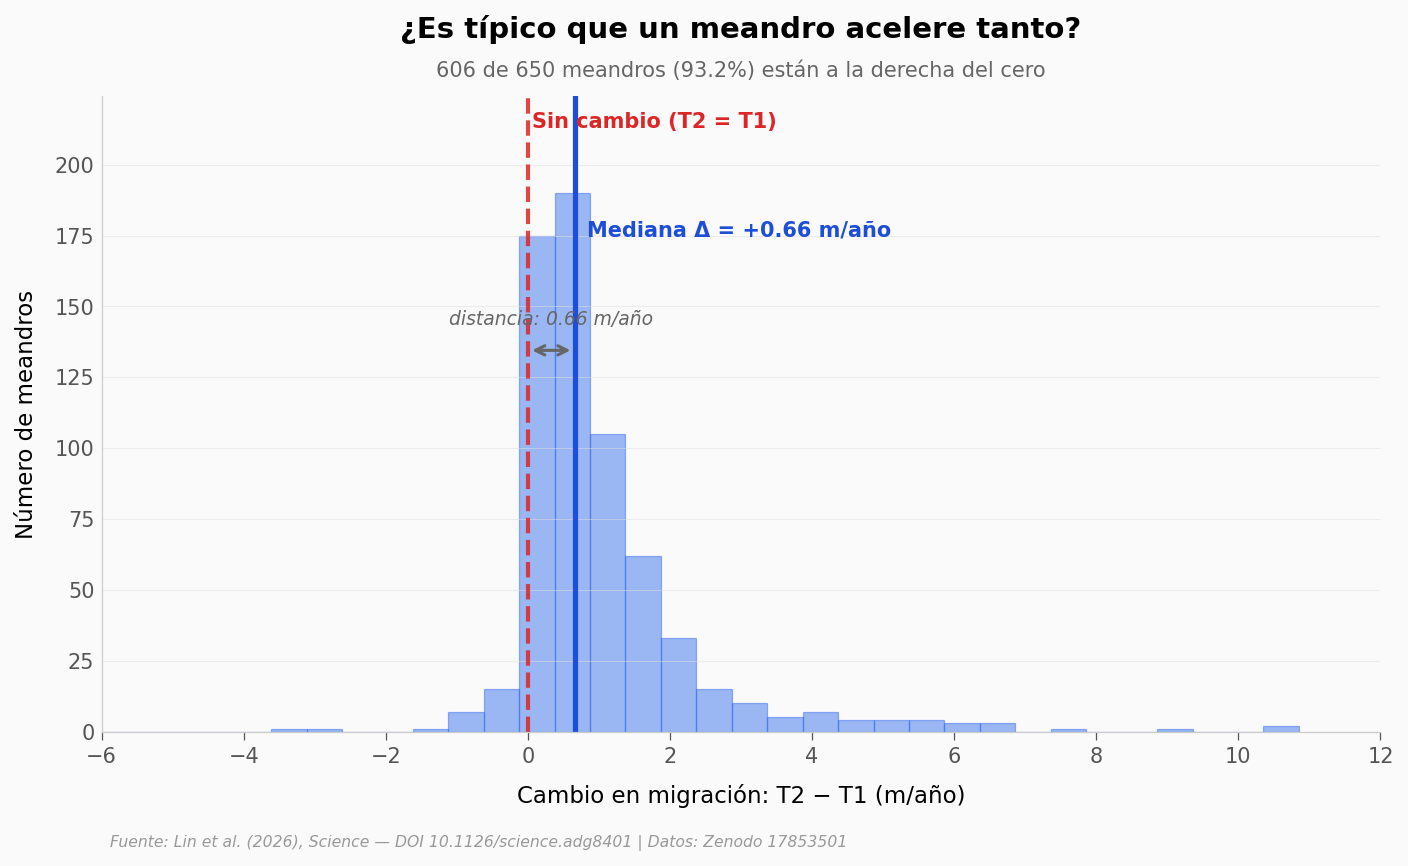

In [5]:
# Histograma de anomalía: Δ Mrm = T2 - T1 por meandro
delta = pareados['migration_m_yr_t2'] - pareados['migration_m_yr_t1']
mediana = delta.median()
media = delta.mean()
n_subio = (delta > 0).sum()
n_total = len(delta)

fig, ax = plt.subplots(figsize=(11, 5.5))
n, bins, patches = ax.hist(delta, bins=40, color=COLOR_T2, alpha=0.45,
                            edgecolor=COLOR_T2, linewidth=0.6)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Cero = sin cambio
ax.axvline(x=0, color=COLOR_ALERTA, linewidth=2.0, linestyle='--', alpha=0.85)
ax.text(0.05, y_max * 0.95, 'Sin cambio (T2 = T1)',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Mediana del Δ
ax.axvline(x=mediana, color='#1d4ed8', linewidth=2.5)
ax.text(mediana + 0.18, y_max * 0.78,
        f'Mediana Δ = +{mediana:.2f} m/año',
        fontsize=10, color='#1d4ed8', fontweight='bold')

# Flecha de anomalía
ax.annotate('', xy=(mediana, y_max * 0.6), xytext=(0, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mediana / 2, y_max * 0.64,
        f'distancia: {mediana:.2f} m/año',
        fontsize=9, color='#666666', ha='center', style='italic')

ax.set_xlabel('Cambio en migración: T2 − T1 (m/año)', fontsize=11)
ax.set_ylabel('Número de meandros', fontsize=11)
ax.set_title('¿Es típico que un meandro acelere tanto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'{n_subio} de {n_total} meandros ({n_subio/n_total*100:.1f}%) están a la derecha del cero',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-6, 12)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color=COLOR_CONTEXTO, style='italic')
plt.savefig('figuras/anomalia_delta.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| La migración mediana ~1,8× T1 → T2 | ✅ | Mediana 1,02 → 1,81 m/año; ratio = 1,77×. Wilcoxon p ≈ 10⁻⁹², d pareado = 0,72. El paper dice "*roughly doubled*" — nuestro cálculo encaja, pero ojo: el Yarlung Tsangpo (75% de la muestra) sube 1,62×, no 2×. |
| El 93% de los meandros aceleró | ✅ | 606 de 650 meandros migraron más rápido en T2. |
| El Ganges es el que más se duplicó | ✅ | Ganges 2,16× · Indus 1,91× · Yarlung 1,62×. |
| La temperatura subió +0,87 °C en la red | ✅ | Media 1980s = −0,63 °C → 2010s = +0,24 °C, n = 2.600 obs. |
| La temperatura *causa* el aumento de migración | ⚠️ | Correlación Spearman ρ = 0,33 (modesta). El paper lo enmarca con verbos atenuados ("*we ascribe*") y lo sostiene con un modelo SEM, no con la comparación pareada. |
| El sedimento *aumentó* (claim del paper sobre "*amplified sediment fluxes*") | ❌ | En los datos crudos, Qs **bajó** ~43% entre 1980s y 2010s. El paper sostiene el "amplified" con su SEM estructural, no con las medias temporales que vemos aquí. |

> **Limitaciones:**
> - **Diseño observacional.** Comparamos dos periodos sin manipular nada — la causalidad clima → migración es hipótesis, no demostración.
> - **Muestra desbalanceada.** El 75% de los meandros son del Yarlung Tsangpo; el "casi se duplicó" global pesa muchísimo ese río.
> - **Dos tablas, dos universos.** Los meandros pareados (Fig 5) y los climáticos por década (Fig 6) usan IDs disjuntos — no se pueden cruzar a nivel de meandro individual.
> - **El "índice glaciar" no es área de hielo.** Sube de 13,5 a 21,8, pero sin metadata pública no podemos interpretarlo como "más glaciar" — probablemente es un índice de contribución al meltwater.

## Ahora tú

1. **¿Qué pasa si miras solo el Yarlung Tsangpo?** El ratio global cae a 1,62× y deja de "casi duplicarse". Filtra `pareados[pareados['cuenca'] == 'Yarlung_Tsangpo']` y recalcula la mediana T1 y T2.
2. **¿La forma del canal importa?** La columna `tipo_canal_codigo` agrupa los meandros por morfología. ¿Aceleran igual los códigos 4 (mayoría) y 5? Prueba un `groupby('tipo_canal_codigo')`.
3. **¿La sinuosidad cambió?** Las columnas `sinuosidad_C_t1` y `sinuosidad_C_t2` miden lo "ondulado" del canal. ¿También aumentó, o solo cambió la velocidad lateral?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: el ratio cuando excluimos el Yarlung Tsangpo
sin_yarlung = pareados[pareados['cuenca'] != 'Yarlung_Tsangpo']
t1m = sin_yarlung['migration_m_yr_t1'].median()
t2m = sin_yarlung['migration_m_yr_t2'].median()
print(f'Sin Yarlung Tsangpo (n={len(sin_yarlung)}):')
print(f'  T1 mediana: {t1m:.3f} m/año')
print(f'  T2 mediana: {t2m:.3f} m/año')
print(f'  Ratio T2/T1: {t2m/t1m:.2f}×')

# Cambia esto y vuelve a correr la celda:
# - Sustituye 'Yarlung_Tsangpo' por 'Ganges' o 'Indus' para aislar una cuenca
# - O agrupa por 'tipo_canal_codigo' para ver si la morfología pesa

Sin Yarlung Tsangpo (n=163):
  T1 mediana: 1.273 m/año
  T2 mediana: 2.614 m/año
  Ratio T2/T1: 2.05×


## Sobre este notebook

**Reproducible:** sí. Los dos CSVs vienen del repositorio Zenodo de los autores (acceso público, sin paywall) y los cálculos están todos en este notebook — Wilcoxon, Cohen's d, Spearman, agrupamientos por cuenca.

**Datos en `datos/`:**
- `meandros_pareados.csv` — 650 meandros × 14 columnas (trim de `Source_data_Fig.5.csv` original).
- `clima_y_migracion_por_decada.csv` — 2.600 observaciones (650 meandros × 4 décadas) con clima y migración (trim de `Fig6_SEM.csv`).

**Licencia:** notebook y figuras bajo CC-BY 4.0. Repo: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).

## Fuentes

**Paper**: [Accelerated Himalayan river meandering and dynamics due to climate change](https://doi.org/10.1126/science.adg8401)  
*Science, 2026-05-14*

**Datos**: [Supporting data — Accelerated Himalayan river meandering and dynamics due to climate change (Lin et al., 2025)](https://doi.org/10.5281/zenodo.17853501)  
*Zenodo, 2025*

*12 afirmaciones del notebook verificadas contra estas fuentes*